### AWS Sagemaker Connected to Snowflake

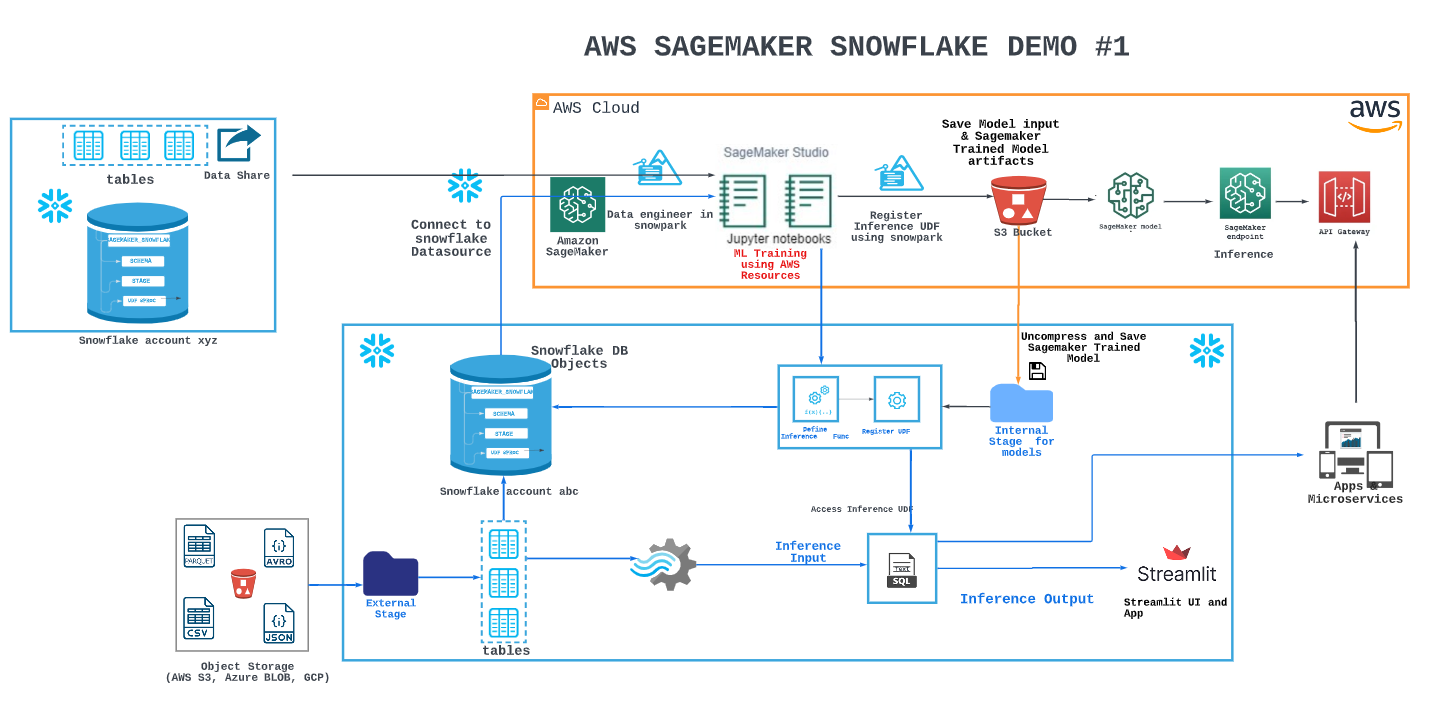

In [15]:
from IPython.display import Image
Image(filename='Sagemaker Snowflake Architecture.png') 

### Install all the required libraries on Python 3.8 version and can be added to lifecycle Configuration

In [2]:
# Install Snowpark
!pip install snowflake-snowpark-python[pandas]==0.10.0

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.6/194.6 kB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 29.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.6 MB/s eta 0:00:00
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 2.2.0
    Uninstalling cloudpickle-2.2.0:
      Successfully uninstalled cloudpickle-2.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2022.11.0 requires tornado<6.2,>=6.0.3, but you have tornado 6.2 which is incompatible.


In [4]:
# Install Basic libraries
!pip install pandas==1.4.3
!pip install numpy==1.22.3
# Install ML libraries that will be used for this machine learning model
!pip install scikit-learn==1.1.1
!pip install lightgbm==3.2.1
!pip install xgboost==1.5.0
# Install Visualization libraries
!pip install scipy==1.7.1
!pip install seaborn==0.11.2
!pip install matplotlib
# Install other Misc libraries
!pip install cloudpickle==2.0.0
!pip install jupyter
!pip install cachetools==4.2.2

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 95.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pandas
    Found existing installation: pandas 1.4.4
    Uninstalling pandas-1.4.4:
      Successfully uninstalled pandas-1.4.4
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 54.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.0
    Uninstalling scikit-learn-1.0:
      Successfully uninstalled scikit-learn-1.0
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.7 MB/s eta 0:00:00a 0:00:01
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.am

### Import all snowpark related libraries and check the version

In [1]:
from snowflake.snowpark.session import Session as snowpark_session
from snowflake.snowpark.functions import avg, sum, col,lit
from snowflake.snowpark.functions import udf, sproc, col
from snowflake.snowpark import functions as F
from snowflake.snowpark import types as T
from snowflake.snowpark.types import IntegerType, FloatType, LongType,DoubleType, DecimalType,StringType, BooleanType, Variant
from snowflake.snowpark.types import PandasSeries, PandasDataFrame
from snowflake.snowpark import functions as fn
from snowflake.snowpark import version
print (f"snowflake snowpark version is: {version.VERSION}")

snowflake snowpark version is: (0, 10, 0)


### Import sagemaker related and other libraries

In [2]:
import urllib
import os
import pandas as pd
import numpy as np
import json
import sagemaker 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import boto3
from sagemaker.amazon.amazon_estimator import get_image_uri 
from sagemaker.session import s3_input, Session
from sagemaker.predictor import csv_serializer 

### Choose your pre created S3 bucket and get the region name

In [3]:
bucket_name = 'ktnadadur'
#get region name
my_region = boto3.session.Session().region_name
print(my_region)

us-west-2


### If you want to create a new bucket, do as below

In [4]:
# new_bucket_name = 'sagemaker_snowflake'
# new_region_name = 'us-west-1'

# #get access of the s3 bucket
# s3 = boto3.resource('s3')
# #create bucket
# try:
#     if  my_region == new_region_name:
#         s3.create_bucket(Bucket=new_bucket_name)
#     print('S3 bucket created successfully')
# except Exception as e:
#     print('S3 error: ',e)

### Set an output path where the trained model will be saved, for this use case let's choose the already created S3 bucket

In [5]:
prefix = 'xgboost_model'
output_path ='s3://{}/{}/output'.format(bucket_name, prefix)
print(output_path)

s3://ktnadadur/xgboost_model/output


### Load dataset in pandas dataframe

In [6]:
try:
    df = pd.read_csv('./Hospital General Information.csv', sep=",", encoding='cp1252')   # provide relative path in s3 bucket
    print('Datafame created successfully')
except Exception as e:
    print('Dataframe creation error: ',e)

Datafame created successfully


### Clean up dataset and define codes for all parameters

In [7]:
df = df.drop(["Hospital overall rating footnote", "Mortality national comparison footnote", 
          "Safety of care national comparison footnote", "Readmission national comparison footnote",
         "Readmission national comparison footnote", "Patient experience national comparison footnote",
         "Effectiveness of care national comparison footnote", "Timeliness of care national comparison footnote",
         "Efficient use of medical imaging national comparison footnote"], axis=1)
df = df.dropna()
df.isnull().sum()
df = df.drop(["County Name", "ZIP Code", "Meets criteria for meaningful use of EHRs", 
                  "Provider ID", "Phone Number"], axis=1)

df = df.drop(["Address", "Hospital Name"], axis=1)
df = df.drop(df[df["Hospital overall rating"] == "Not Available"].index)

df = df.drop(df[df["Mortality national comparison"] == "Not Available"].index)
df = df.drop(df[df["Safety of care national comparison"] == "Not Available"].index)
df = df.drop(df[df["Patient experience national comparison"] == "Not Available"].index)
df = df.drop(df[df["Effectiveness of care national comparison"] == "Not Available"].index)
df = df.drop(df[df["Timeliness of care national comparison"] == "Not Available"].index)
df = df.drop(df[df["Efficient use of medical imaging national comparison"] == "Not Available"].index)
df = df.drop("City", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2297 entries, 0 to 4784
Data columns (total 12 columns):
 #   Column                                                Non-Null Count  Dtype 
---  ------                                                --------------  ----- 
 0   State                                                 2297 non-null   object
 1   Hospital Type                                         2297 non-null   object
 2   Hospital Ownership                                    2297 non-null   object
 3   Emergency Services                                    2297 non-null   object
 4   Hospital overall rating                               2297 non-null   object
 5   Mortality national comparison                         2297 non-null   object
 6   Safety of care national comparison                    2297 non-null   object
 7   Readmission national comparison                       2297 non-null   object
 8   Patient experience national comparison                2297 non-null 

### Get dummies for all categorical variables and expand dataset by each state

In [8]:
clean_state = pd.get_dummies(df["State"], prefix="State", drop_first=True, dtype=int)
df = pd.concat([df.drop("State", axis=1), clean_state], axis=1)
df.head()
dummy_column = df.iloc[:, 0:3]
clean_column = pd.get_dummies(dummy_column, drop_first=True, dtype=int)
df = pd.concat([df.drop(dummy_column, axis=1), clean_column], axis=1)
df.head()
dummy_column = df.iloc[:,1:8]
clean_column = pd.get_dummies(dummy_column, drop_first=True, dtype=int)
df = pd.concat([df.drop(dummy_column, axis=1), clean_column], axis=1)
df.head()
df["Hospital overall rating"] = df["Hospital overall rating"].astype(str).astype(int)
df.head()

,Hospital overall rating,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,...,Readmission national comparison_Below the national average,Readmission national comparison_Same as the national average,Patient experience national comparison_Below the national average,Patient experience national comparison_Same as the national average,Effectiveness of care national comparison_Below the national average,Effectiveness of care national comparison_Same as the national average,Timeliness of care national comparison_Below the national average,Timeliness of care national comparison_Same as the national average,Efficient use of medical imaging national comparison_Below the national average,Efficient use of medical imaging national comparison_Same as the national average
0,3,1,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,0,1,0,1
1,3,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0
2,2,1,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,1
5,2,1,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,1,0,1
6,3,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,0,1


### Evaluate the dataframe and check the output Y variable distribution

<AxesSubplot:xlabel='Hospital overall rating', ylabel='count'>

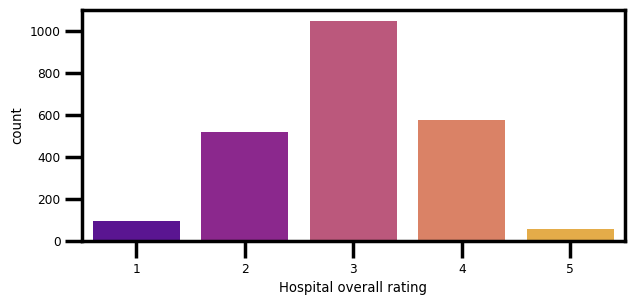

In [9]:
plt.figure(figsize=(7,3))
sns.set_context("poster", font_scale=0.4)
sns.countplot(x=df["Hospital overall rating"], palette="plasma")

In [10]:
df.describe()

,Hospital overall rating,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,...,Readmission national comparison_Below the national average,Readmission national comparison_Same as the national average,Patient experience national comparison_Below the national average,Patient experience national comparison_Same as the national average,Effectiveness of care national comparison_Below the national average,Effectiveness of care national comparison_Same as the national average,Timeliness of care national comparison_Below the national average,Timeliness of care national comparison_Same as the national average,Efficient use of medical imaging national comparison_Below the national average,Efficient use of medical imaging national comparison_Same as the national average
count,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.00000,...,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000
mean,2.994776,0.021332,0.011754,0.016979,0.075751,0.016108,0.011754,0.003047,0.002612,0.06182,...,0.328254,0.353069,0.378320,0.333478,0.063561,0.883761,0.353069,0.413148,0.133217,0.711798
std,0.862482,0.144521,0.107802,0.129219,0.264657,0.125918,0.107802,0.055132,0.051053,0.24088,...,0.469680,0.478028,0.485074,0.471558,0.244023,0.320581,0.478028,0.492506,0.339883,0.453024
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Convert the output Y Variable to binary where 1,2,3 == 0 and 4,5 == 1

In [11]:
df["Hospital overall rating"] = df["Hospital overall rating"].map({1:0, 2:0, 3:0, 4:1, 5:1})
df["Hospital overall rating"].value_counts()
df.describe()

,Hospital overall rating,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,...,Readmission national comparison_Below the national average,Readmission national comparison_Same as the national average,Patient experience national comparison_Below the national average,Patient experience national comparison_Same as the national average,Effectiveness of care national comparison_Below the national average,Effectiveness of care national comparison_Same as the national average,Timeliness of care national comparison_Below the national average,Timeliness of care national comparison_Same as the national average,Efficient use of medical imaging national comparison_Below the national average,Efficient use of medical imaging national comparison_Same as the national average
count,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.00000,...,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000
mean,0.276883,0.021332,0.011754,0.016979,0.075751,0.016108,0.011754,0.003047,0.002612,0.06182,...,0.328254,0.353069,0.378320,0.333478,0.063561,0.883761,0.353069,0.413148,0.133217,0.711798
std,0.447556,0.144521,0.107802,0.129219,0.264657,0.125918,0.107802,0.055132,0.051053,0.24088,...,0.469680,0.478028,0.485074,0.471558,0.244023,0.320581,0.478028,0.492506,0.339883,0.453024
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<AxesSubplot:xlabel='Hospital overall rating', ylabel='count'>

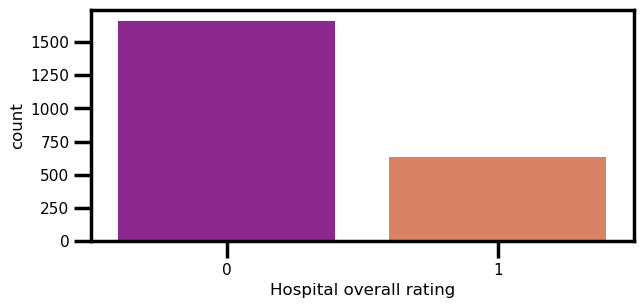

In [12]:
plt.figure(figsize=(7,3))
sns.set_context("poster", font_scale=0.5)
sns.countplot(x=df["Hospital overall rating"], palette="plasma")

### Connect to snowflake

In [13]:
snowflake_connection_cfg = open('cred.json')
snowflake_connection_cfg = snowflake_connection_cfg.read()
snowflake_connection_cfg = json.loads(snowflake_connection_cfg)

# Creating Snowpark Session

load_session = snowpark_session.builder.configs(snowflake_connection_cfg).create()
print('Current Database:', load_session.get_current_database())
print('Current Schema:', load_session.get_current_schema())
print('Current Warehouse:', load_session.get_current_warehouse())
print('Current role:', load_session.get_current_role())
print("Warehouse set up:")
load_session.sql("show warehouses like 'APP_WH'").collect()

Current Database: "SAGEMAKER_SNOWFLAKE_DEMO"
Current Schema: "PUBLIC"
Current Warehouse: "APP_WH"
Current role: "SYSADMIN"
Warehouse set up:


[Row(name='APP_WH', state='SUSPENDED', type='STANDARD', size='Medium', min_cluster_count=1, max_cluster_count=5, started_clusters=0, running=0, queued=0, is_default='N', is_current='Y', auto_suspend=600, auto_resume='true', available='', provisioning='', quiescing='', other='', created_on=datetime.datetime(2022, 2, 27, 4, 51, 57, 85000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), resumed_on=datetime.datetime(2023, 3, 1, 15, 21, 1, 609000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), updated_on=datetime.datetime(2023, 3, 1, 15, 21, 1, 609000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), owner='SYSADMIN', comment='', enable_query_acceleration='false', query_acceleration_max_scale_factor=8, resource_monitor='null', actives=0, pendings=0, failed=0, suspended=4, uuid='1463550724', scaling_policy='STANDARD')]

### Load Curated data into a snowflake table

In [14]:
load_session.create_dataframe(df).write.mode("overwrite").save_as_table("cms_curated")

create_temp_table is deprecated. We still respect this parameter when it is True but please consider using `table_type="temporary"` instead.


### Read the snowflake table in a snowpark dataframe

In [15]:
df_input = load_session.table("cms_curated")
df_input.show(3)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### We can also convert the data back to pandas format

In [16]:
df1 = df_input.to_pandas()
df1

,Hospital overall rating,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,...,Readmission national comparison_Below the national average,Readmission national comparison_Same as the national average,Patient experience national comparison_Below the national average,Patient experience national comparison_Same as the national average,Effectiveness of care national comparison_Below the national average,Effectiveness of care national comparison_Same as the national average,Timeliness of care national comparison_Below the national average,Timeliness of care national comparison_Same as the national average,Efficient use of medical imaging national comparison_Below the national average,Efficient use of medical imaging national comparison_Same as the national average
0,0,1,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,0,1,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,1
3,0,1,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,1,0,1
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2292,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
2293,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,0,1
2294,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,1
2295,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1


### Split the X and y variables to evaluate the model locally

In [17]:
X = df.drop("Hospital overall rating", axis=1)
y = df["Hospital overall rating"]

### To test this locally using knearest neighbors, let's split the data as train and test

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
neighbor = KNeighborsClassifier(n_neighbors=10)
neighbor.fit(X_train, y_train)
neighbor_predict = neighbor.predict(X_test)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, neighbor_predict))
print(classification_report(y_test, neighbor_predict))

[[315  19]
 [ 52  74]]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       334
           1       0.80      0.59      0.68       126

    accuracy                           0.85       460
   macro avg       0.83      0.77      0.79       460
weighted avg       0.84      0.85      0.84       460



### Now that we know the models work as expected with the input data prepared. Let's try to build the model on Sagemaker using XGBoost

In [21]:
# Train and test data split
train_data, test_data = np.split(df.sample(frac=1, random_state=1729), [int(0.8 * len(df))])
print(train_data.shape, test_data.shape)

(1837, 74) (460, 74)


### With first column being Output Y variable on training data and saved as csv

In [22]:
train_data.to_csv('train.csv', index=False, header=False)
# upload data to s3 bucket under the 'train' folder
boto3.Session().resource('s3').Bucket(bucket_name).Object(os.path.join(prefix, 'train/train.csv')).upload_file('train.csv')
# for general upload of the we will reuire path of the data next time 
s3_input_train = sagemaker.TrainingInput(s3_data='s3://{}/{}/train'.format(bucket_name, prefix), content_type='csv')

### With first column being Output Y variable on test data and saved as csv

In [23]:
test_data.to_csv('test.csv', index=False, header=False)
boto3.Session().resource('s3').Bucket(bucket_name).Object(os.path.join(prefix, 'test/test.csv')).upload_file('test.csv')
s3_input_test = sagemaker.TrainingInput(s3_data='s3://{}/{}/test'.format(bucket_name, prefix), content_type='csv')

### Bring the xgboost images on sagemaker with the latest version

In [24]:
# xgboost_container = get_image_uri(boto3.Session().region_name,'xgboost', repo_version='latest')
# Specify XGBoost algorithm container
xgboost_container = sagemaker.image_uris.retrieve("xgboost", boto3.Session().region_name, "1.3-1")

### These hyperparameter tuning parameters determined after multiple iterations run locally finding the boundaries

In [25]:
hyperparameters = {
        "max_depth":"5",
        "eta":"0.2",
        "gamma":"4",
        "min_child_weight":"6",
        "subsample":"0.7",
        "objective":"binary:logistic",
        "num_round":50
        }

### Specify the model parameters for a given container with the instance type to train the model.

In [26]:
estimator = sagemaker.estimator.Estimator(image_uri=xgboost_container, 
                                          hyperparameters=hyperparameters,
                                          role=sagemaker.get_execution_role(),
                                          train_instance_count=1, 
                                          train_instance_type='ml.m5.2xlarge', 
                                          train_volume_size=5, # 5 GB 
                                          output_path=output_path,
                                          train_use_spot_instances=True,
                                          train_max_run=300,
                                          train_max_wait=600)

train_instance_count has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_instance_type has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_max_run has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_use_spot_instances has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_max_wait has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_volume_size has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


### Train the Model using the model parameters above and generate the model artifacts

In [27]:
# final training of the model given the chosen paramters
estimator.fit({'train': s3_input_train,'validation': s3_input_test})

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2023-02-28-19-33-39-415


2023-02-28 19:33:39 Starting - Starting the training job...
2023-02-28 19:33:56 Starting - Preparing the instances for training.........
2023-02-28 19:35:23 Downloading - Downloading input data...
2023-02-28 19:35:59 Training - Training image download completed. Training in progress...[2023-02-28 19:36:22.589 ip-10-0-113-195.us-west-2.compute.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2023-02-28 19:36:22.612 ip-10-0-113-195.us-west-2.compute.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2023-02-28:19:36:22:INFO] Imported framework sagemaker_xgboost_container.training
[2023-02-28:19:36:22:INFO] Failed to parse hyperparameter objective value binary:logistic to Json.
Returning the value itself
[2023-02-28:19:36:22:INFO] No GPUs detected (normal if no gpus installed)
[2023-02-28:19:36:22:INFO] Running XGBoost Sagemaker in algorithm mode
[2023-02-28:19:36:22:INFO] Determined delimiter of CSV input is ','
[2023-02-28:19:36:22:INFO] Determi

### Deploy the model that was trained and create an endpoint on AWS

In [28]:
xgb_predictor = estimator.deploy(initial_instance_count=1,instance_type='ml.m4.xlarge')

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2023-02-28-19-37-40-258
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2023-02-28-19-37-40-258
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2023-02-28-19-37-40-258


-------!

### Generate the test data as array to test the prediction on the endpoint

In [44]:
test_data_array = test_data.drop(['Hospital overall rating'], axis=1).values #load the data into an array
xgb_predictor.serializer = csv_serializer # set the serializer type
predictions = xgb_predictor.predict(test_data_array).decode('utf-8') # predict!
# predictions_array = np.fromstring(predictions, sep=',') # and turn the prediction into an array
predictions_array = [float(line) for line in predictions.split('\n') if line.strip() != '']

See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [45]:
np.round(predictions_array)[:100]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

### Compare the predict vs observed confusion matrix


Overall Classification Rate: 86.1%



<AxesSubplot:xlabel='Predicted', ylabel='Observed'>

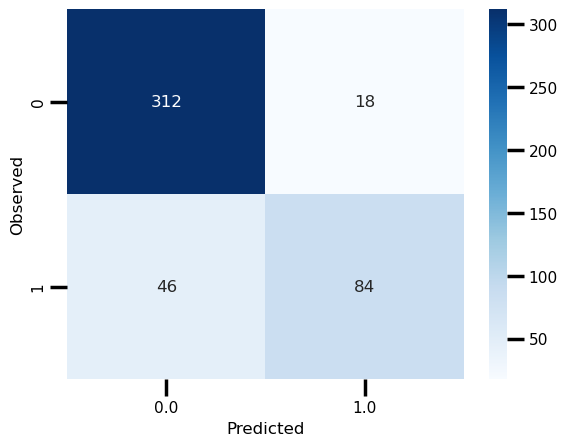

In [31]:
cm = pd.crosstab(index=test_data['Hospital overall rating'], columns=np.round(predictions_array), rownames=['Observed'], colnames=['Predicted'])
tn = cm.iloc[0,0]; fn = cm.iloc[1,0]; tp = cm.iloc[1,1]; fp = cm.iloc[0,1]; p = (tp+tn)/(tp+tn+fp+fn)*100
print("\n{0:<20}{1:<4.1f}%\n".format("Overall Classification Rate: ", p))
# print("{0:<15}{1:<15}{2:>8}".format("Predicted", "0", "1"))
# print("Observed")
# print("{0:<15}{1:<2.0f}% ({2:<}){3:>6.0f}% ({4:<})".format("0", tn/(tn+fn)*100,tn, fp/(tp+fp)*100, fp))
# print("{0:<16}{1:<1.0f}% ({2:<}){3:>7.0f}% ({4:<}) \n".format("1", fn/(tn+fn)*100,fn, tp/(tp+fp)*100, tp))
sns.heatmap(cm, annot=True,fmt="d",cmap='Blues')  # cmap='OrRd'

### Delete the endpoint that was created above if you dont need it anymore

In [245]:
sagemaker.Session().delete_endpoint(xgb_predictor.endpoint)

INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2023-02-26-07-53-22-942


In [47]:
create_dataframe(train_data)

NameError: name 'create_dataframe' is not defined

### Now let's see how we can deploy the AWS Sagemaker developed model on Snowflake as User Defined Function and perform inference in simple SQL

### Create Internal Stages to load the model files. UDF can only be registered using internal stage

In [229]:
# Creating stages for functions, models
load_session.sql("CREATE or replace STAGE SAGEMAKER_SNOWFLAKE_MODELS").collect()

INFO:snowflake.connector.cursor:query: [CREATE STAGE IF NOT EXISTS FUNCTIONS]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [CREATE or replace STAGE SAGEMAKER_SNOWFLAKE_MODELS]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1


[Row(status='Stage area SAGEMAKER_SNOWFLAKE_MODELS successfully created.')]

### Locate the model file trained using AWS Sagemaker in the S3 bucket

In [32]:
estimator.model_data

's3://ktnadadur/xgboost_model/output/sagemaker-xgboost-2023-02-28-19-33-39-415/output/model.tar.gz'

### Passing the model path as input let's try to download the model zip file and uncompress to local Sagemaker location

In [33]:
def download_from_s3(url):
    """ex: url = s3://sagemakerbucketname/model/model.tar.gz"""
    url_parts = url.split("/")  # => ['s3:', '', 'sagemakerbucketname', 'model', ...
    bucket_name = url_parts[2]
    key = os.path.join(*url_parts[3:])
    filename = url_parts[-1]
    print('Trying to download {} to {}'.format(url, filename))
    if not os.path.exists(filename):
        try:
            # Create an S3 client
            s3 = boto3.Session().resource("s3")
            print('Downloading {} to {}'.format(url, filename))
            s3.Bucket(bucket_name).download_file(key, filename, )
        except botocore.exceptions.ClientError as e:
            if e.response['Error']['Code'] == "404":
                print('The object {} does not exist in bucket {}'.format(
                    key, bucket_name))
            else:
                raise
# Download the compressed model from S3
download_from_s3(estimator.model_data)
# Extract the model file
import tarfile
t = tarfile.open('model.tar.gz', 'r:gz')
t.extractall()

Trying to download s3://ktnadadur/xgboost_model/output/sagemaker-xgboost-2023-02-28-19-33-39-415/output/model.tar.gz to model.tar.gz


### Before we register the snowpark UDF, let's make sure if the model file downloaded works as expected

In [34]:
def predict_rating(arg: list) -> list:
    import sys
    import numpy as np
    import xgboost as xgb
    
    xgb_model = xgb.Booster()
    xgb_model.load_model('xgboost-model')
    np_rows = np.array(arg) #np.array([arg])
    row_DMatrix = xgb.DMatrix(np_rows)
    return [round(x) for x in xgb_model.predict(row_DMatrix)]
# predict_rating(my_input)

In [35]:
my_input = df.iloc[:,1:].values.tolist()
load_session.create_dataframe(df).write.mode("overwrite").save_as_table("cms_test_data")

INFO:snowflake.connector.cursor:query: [CREATE TEMP STAGE /* Python:snowflake.connector.pandas_tools.write_pandas() */ "...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [PUT /* Python:snowflake.connector.pandas_tools.write_pandas() */ 'file:///tmp/tm...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:query: [CREATE TEMP FILE FORMAT "SAGEMAKER_SNOWFLAKE_DEMO"."PUBLIC"."ernckzwbdm" /* Pyth...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [SELECT COLUMN_NAME, TYPE FROM table(infer_schema(location=>'@"SAGEMAKER_SNOWFLAK...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 75
INFO:snowflake.connector.cursor:query: [CREATE TEMPORARY TABLE IF NOT EXISTS "SAGEM

### Define the snowpark UDF from the model file

In [36]:
import cachetools
@cachetools.cached(cache={})
def load_model(filename):
    import joblib
    import sys
    import os
    import xgboost as xgb

    IMPORT_DIRECTORY_NAME = "snowflake_import_directory"
    import_dir = sys._xoptions[IMPORT_DIRECTORY_NAME]

    if import_dir:
    
        xgb_model = xgb.Booster()
        xgb_model.load_model(os.path.join(import_dir, filename))
        
        return xgb_model
    
def predict_rating_udf(ds: T.PandasSeries[list]) -> T.PandasSeries[int]:
    import numpy as np
    import xgboost as xgb
    
    xgb_model = load_model('xgboost-model')
    
    np_rows = np.array(ds.tolist())
    
    row_DMatrix = xgb.DMatrix(np_rows)
    return [round(x) for x in xgb_model.predict(row_DMatrix)]

### Register UDF from the function defined above

In [37]:
load_session.clear_imports()
load_session.clear_packages()
load_session.add_import("xgboost-model")
load_session.add_packages("numpy","pandas","xgboost==1.3.3", "cachetools")

predict_churn = load_session.udf.register(func=predict_rating_udf, name="predict_rating_udf"
                                        ,stage_location="@SAGEMAKER_SNOWFLAKE_MODELS", is_permanent = True, replace=True)

INFO:snowflake.connector.cursor:query: [select package_name, version from information_schema.packages where language='py...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 4655
INFO:snowflake.connector.cursor:query: [ls '@SAGEMAKER_SNOWFLAKE_MODELS']
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [SELECT "name" FROM ( SELECT  *  FROM  TABLE ( RESULT_SCAN('01aaa3a1-0402-9e57-00...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [CREATE OR REPLACE FUNCTION predict_rating_udf(arg1 ARRAY) RETURNS BIGINT LANGUAG...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1


### Check the model that has been saved from the add_import

In [234]:
load_session.sql("list @SAGEMAKER_SNOWFLAKE_MODELS").collect()

INFO:snowflake.connector.cursor:query: [list @SAGEMAKER_SNOWFLAKE_MODELS]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1


[Row(name='sagemaker_snowflake_models/26e67fda27da055ecf01f959d4a9b3ca7ade4ab3474593be00c94577433f95d1/xgboost-model', size=49376, md5='44ba78a8d9e58e826c9315fcf9529cd2', last_modified='Sun, 26 Feb 2023 08:57:39 GMT')]

### Call the UDF registered above using the input as a snowpark dataframe from local

In [38]:
udf_test_df = load_session.create_dataframe(my_input)
# display(udf_test_df.show())
display(udf_test_df.select(F.call_udf("predict_rating_udf", F.array_construct('*')).as_("pred_rating")).show())

INFO:snowflake.connector.cursor:query: [CREATE  OR  REPLACE  SCOPED TEMPORARY  TABLE SNOWPARK_TEMP_TABLE_6N1L6MPLA3("_1"...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [alter session set query_tag = '  File "/home/ec2-user/anaconda3/envs/mxnet_p38/l...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [create or replace temporary stage SYSTEMBIND file_format=(type=csv field_optiona...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [PUT file://2297.csv @SYSTEMBIND/508d6247e3754e8e89f08675eca893c2]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:query: [INSERT  INTO SNOWPARK_TEMP_TABLE_6N1L6MPLA3("_1", "_2", "_3", "

-----------------
|"PRED_RATING"  |
-----------------
|0              |
|0              |
|0              |
|0              |
|0              |
|0              |
|0              |
|1              |
|0              |
|1              |
-----------------



None

### Infer Using the snowpark table

In [41]:
udf_test_df_table = load_session.create_dataframe(load_session.table("cms_test_data").to_pandas().iloc[:,1:].values.tolist())
# display(udf_test_df.show())
display(udf_test_df_table.select(F.call_udf("predict_rating_udf", F.array_construct('*')).as_("pred_rating")).show())

INFO:snowflake.connector.cursor:query: [SELECT  *  FROM (cms_test_data)]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1792
INFO:snowflake.connector.cursor:query: [CREATE  OR  REPLACE  SCOPED TEMPORARY  TABLE SNOWPARK_TEMP_TABLE_WC80MTCBZL("_1"...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [alter session set query_tag = '  File "/home/ec2-user/anaconda3/envs/mxnet_p38/l...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [create or replace temporary stage SYSTEMBIND file_format=(type=csv field_optiona...]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:query: [PUT file://2297.csv @SYST

-----------------
|"PRED_RATING"  |
-----------------
|0              |
|0              |
|0              |
|0              |
|0              |
|0              |
|0              |
|1              |
|0              |
|1              |
-----------------



None

### Close the session

In [14]:
load_session.close()